# From Materials Data to Inverse Design
### A hands-on companion notebook — AMALGAM Lecture, IIT Madras

This notebook walks through the **same narrative as the lecture**, as a single
runnable pipeline:

1. **Data Inspection** — look at a real-shaped (synthetic) alloy dataset before trusting it
2. **Data Cleaning** — fix messy text, handle missing values, remove duplicates
3. **Exploratory Data Analysis (EDA)** — distributions, correlations, physical sanity checks
4. **Forward Prediction (ML workflow)** — Structure → Property, with a Random Forest
5. **Inverse Design** — Property → Structure, using an autoencoder + latent-space optimization
6. **MLIP Concept Demo** — a *conceptual*, illustrative look at how machine-learned interatomic potentials extend this idea to atomic-scale simulation

**How to use this notebook:** run the cells top to bottom. Markdown cells explain
*why* each step matters scientifically, not just what the code does. Section 5
reuses the exact autoencoder / predictor / optimization code style shown in the
lecture, applied to the same 6 structural descriptors (`a, b, c, x, y, z`) and
3 properties (`density, bandgap, strength`).

> **Required packages:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `torch`.
> If any import fails, run:
> ```bash
> pip install numpy pandas matplotlib seaborn scikit-learn torch
> ```
> (see the **Setup** cell below, which checks this for you.)


## Setup

Run this cell first. It checks that every package this notebook needs is
installed, and creates the synthetic alloy dataset used in Sections 1–4
(`data/alloys_dataset.csv`) if it isn't already present, so the notebook is
fully self-contained and reproducible.


In [1]:
import importlib, subprocess, sys

REQUIRED = ["numpy", "pandas", "matplotlib", "seaborn", "sklearn", "torch"]
missing = [pkg for pkg in REQUIRED if importlib.util.find_spec(pkg) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing])
else:
    print("All required packages are already installed:", REQUIRED)


All required packages are already installed: ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'torch']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
RNG_SEED = 42
np.random.seed(RNG_SEED)

print("Environment ready.")


Environment ready.


### About the dataset

The dataset below is a **synthetic but realistically messy** alloy dataset —
the same one used to generate the EDA figures in the lecture. Each row is an
alloy sample with elemental composition (wt%) drawn from five alloy families
(Al-Cu wrought, Al-Mg wrought, Al-Zn-Mg, Low-C steel, Ni-Cr steel), a melting
point, and a measured Tensile Strength (UTS).

It is deliberately **not clean**: it has missing values (including missing
*not at random* — melting point is disproportionately missing for one alloy
family), a few non-numeric placeholder strings in one composition column, and
a couple of duplicate rows. This is intentional — Sections 1–2 exist precisely
to catch and fix these issues, exactly as you would with real experimental or
literature-mined materials data.


In [3]:
import os

DATA_PATH = "data/alloys_dataset.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    rng = np.random.default_rng(7)
    N = 220

    families = (
        ["Al-Cu wrought"] * 50 + ["Al-Mg wrought"] * 40 + ["Al-Zn-Mg"] * 40 +
        ["Low-C steel"] * 50 + ["Ni-Cr steel"] * 40
    )
    rng.shuffle(families)
    families = np.array(families[:N])
    is_steel = np.isin(families, ["Low-C steel", "Ni-Cr steel"])

    Fe = np.where(is_steel, rng.normal(95.5, 2.6, N), rng.normal(1.2, 1.1, N)).clip(0, 100)
    Al = np.where(is_steel, rng.normal(0.6, 0.7, N), rng.normal(91.0, 4.2, N)).clip(0, 100)
    Cu = np.where(families == "Al-Cu wrought", rng.normal(4.0, 0.9, N), rng.exponential(0.5, N)).clip(0, None)
    Mg = np.where(np.isin(families, ["Al-Mg wrought", "Al-Zn-Mg"]), rng.normal(2.5, 0.8, N), rng.exponential(0.2, N)).clip(0, None)
    Zn = np.where(families == "Al-Zn-Mg", rng.normal(5.5, 1.1, N), rng.exponential(0.15, N)).clip(0, None)
    Mn = rng.exponential(0.3, N)
    Si = rng.exponential(0.25, N)
    Ni = np.where(families == "Ni-Cr steel", rng.normal(8.0, 1.5, N), rng.exponential(0.1, N)).clip(0, None)
    Cr = np.where(families == "Ni-Cr steel", rng.normal(18.0, 1.8, N), rng.exponential(0.1, N)).clip(0, None)
    Ce = rng.exponential(0.05, N)
    Ca = rng.exponential(0.03, N)

    melting_point = np.where(
        is_steel, rng.normal(1500, 25, N), rng.normal(650, 20, N)
    ) + rng.normal(0, 20, N)

    uts = (
        50 + 3.2 * Cu + 4.1 * Zn + 2.8 * Mg + 1.1 * Ni + 0.9 * Cr
        + 0.35 * (melting_point - 650) * (~is_steel)
        + 0.15 * (melting_point - 1500) * is_steel
        + rng.normal(0, 12, N)
    ).clip(50, None)

    df_gen = pd.DataFrame({
        "Alloy Family": families, "Fe": Fe, "Al": Al, "Cu": Cu, "Mg": Mg, "Zn": Zn,
        "Mn": Mn, "Si": Si, "Ni": Ni, "Cr": Cr, "Ce": Ce, "Ca": Ca,
        "Melting Point (C)": melting_point, "Tensile Strength UTS (MPa)": uts,
    }).round(3)

    # missing NOT at random: Ni-Cr steel disproportionately missing melting point
    steel_idx = df_gen.index[df_gen["Alloy Family"] == "Ni-Cr steel"]
    drop_mp = rng.choice(steel_idx, size=min(15, len(steel_idx)), replace=False)
    df_gen.loc[drop_mp, "Melting Point (C)"] = np.nan

    # a handful of missing UTS values, missing at random
    drop_uts = rng.choice(df_gen.index, size=8, replace=False)
    df_gen.loc[drop_uts, "Tensile Strength UTS (MPa)"] = np.nan

    # inject messy placeholder text into the Cu column
    placeholders = ["n/a", "--", "not measured", "trace", "TBD"]
    df_gen["Cu"] = df_gen["Cu"].astype(object)
    messy_idx = rng.choice(df_gen.index, size=5, replace=False)
    for i, ph in zip(messy_idx, placeholders):
        df_gen.loc[i, "Cu"] = ph

    # duplicate a couple of rows
    df_gen = pd.concat([df_gen, df_gen.iloc[[3, 40]]], ignore_index=True)

    df_gen.to_csv(DATA_PATH, index=False)
    print(f"Generated synthetic dataset -> {DATA_PATH}  ({df_gen.shape[0]} rows)")
else:
    print(f"Using existing dataset -> {DATA_PATH}")


Generated synthetic dataset -> data/alloys_dataset.csv  (222 rows)


---
## 1. Data Inspection

Before any modelling, the first scientific question is: **what does this
dataset actually contain, and can I trust it?** `head()`, `info()`, and
`describe()` are the fastest way to answer that.


In [4]:
df = pd.read_csv(DATA_PATH)
df.head()


,Alloy Family,Fe,Al,Cu,Mg,Zn,Mn,Si,Ni,Cr,Ce,Ca,Melting Point (C),Tensile Strength UTS (MPa)
0,Ni-Cr steel,94.043,0.561,0.269,0.028,0.040,0.368,0.029,9.242,18.831,0.109,0.012,1517.330,88.937
1,Low-C steel,95.521,1.112,0.076,0.123,0.303,0.046,0.068,0.116,0.069,0.053,0.121,1555.003,85.095
2,Ni-Cr steel,94.524,1.009,0.273,0.228,0.249,0.222,0.001,6.272,15.383,0.129,0.011,NaN,50.000
3,Al-Zn-Mg,3.684,97.863,0.212,1.774,4.398,0.362,0.017,0.161,0.034,0.097,0.048,635.428,65.984
4,Ni-Cr steel,91.916,0.878,0.623,0.167,0.361,1.143,0.114,5.825,20.085,0.038,0.042,1448.123,82.995


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Alloy Family                222 non-null    str    
 1   Fe                          222 non-null    float64
 2   Al                          222 non-null    float64
 3   Cu                          221 non-null    str    
 4   Mg                          222 non-null    float64
 5   Zn                          222 non-null    float64
 6   Mn                          222 non-null    float64
 7   Si                          222 non-null    float64
 8   Ni                          222 non-null    float64
 9   Cr                          222 non-null    float64
 10  Ce                          222 non-null    float64
 11  Ca                          222 non-null    float64
 12  Melting Point (C)           207 non-null    float64
 13  Tensile Strength UTS (MPa)  214 non-null    fl

In [6]:
df.describe()


,Fe,Al,Mg,Zn,Mn,Si,Ni,Cr,Ce,Ca,Melting Point (C),Tensile Strength UTS (MPa)
count,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,207.000000,214.000000
mean,39.200955,54.397599,1.047955,1.185441,0.321568,0.223234,1.465450,3.322167,0.045410,0.027099,955.274638,68.552631
std,46.303231,44.597661,1.234998,2.202226,0.333000,0.229553,2.997125,6.934311,0.048363,0.028849,409.706564,15.918678
min,0.000000,0.000000,0.002000,0.000000,0.000000,0.001000,0.000000,0.002000,0.000000,0.000000,580.877000,50.000000
25%,0.777000,0.780000,0.124750,0.051500,0.087750,0.059750,0.034250,0.037000,0.013000,0.006250,640.058500,53.677250
50%,2.048000,86.712500,0.310000,0.146000,0.206500,0.153500,0.091000,0.086000,0.028000,0.017000,666.622000,66.089000
75%,94.644750,91.418500,2.042750,0.403250,0.448000,0.307000,0.232000,0.240750,0.057750,0.039500,1476.187000,78.559250
max,100.000000,100.000000,4.891000,7.700000,1.948000,1.320000,11.024000,21.950000,0.262000,0.201000,1572.949000,117.134000


Two things should immediately catch your eye:

- **`Cu` is listed as an `object` column**, not numeric — even though it should be a wt% composition.
- **`Melting Point (C)` and `Tensile Strength UTS (MPa)`** have fewer non-null entries than the other 220+ rows.

We'll deal with both in Section 2. First, some basic indexing.


In [7]:
# .loc[] selects by LABEL (the row's index value)
df.loc[4]


Alloy Family                  Ni-Cr steel
Fe                                 91.916
Al                                  0.878
Cu                                  0.623
Mg                                  0.167
Zn                                  0.361
Mn                                  1.143
Si                                  0.114
Ni                                  5.825
Cr                                 20.085
Ce                                  0.038
Ca                                  0.042
Melting Point (C)                1448.123
Tensile Strength UTS (MPa)         82.995
Name: 4, dtype: object

In [8]:
# .iloc[] selects by POSITION, regardless of the label
df.iloc[4]


Alloy Family                  Ni-Cr steel
Fe                                 91.916
Al                                  0.878
Cu                                  0.623
Mg                                  0.167
Zn                                  0.361
Mn                                  1.143
Si                                  0.114
Ni                                  5.825
Cr                                 20.085
Ce                                  0.038
Ca                                  0.042
Melting Point (C)                1448.123
Tensile Strength UTS (MPa)         82.995
Name: 4, dtype: object

In [9]:
# Selecting a single column by label
df["Alloy Family"].value_counts()


Alloy Family
Low-C steel      50
Al-Cu wrought    50
Al-Zn-Mg         42
Ni-Cr steel      40
Al-Mg wrought    40
Name: count, dtype: int64

### Boolean masking

Masking filters rows using a `True`/`False` array — e.g. "show me only the
high-strength alloys."


In [10]:
mask_high_strength = df["Tensile Strength UTS (MPa)"] > 300
print(f"{mask_high_strength.sum()} of {len(df)} rows exceed 300 MPa UTS")
df.loc[mask_high_strength].head()


0 of 222 rows exceed 300 MPa UTS


,Alloy Family,Fe,Al,Cu,Mg,Zn,Mn,Si,Ni,Cr,Ce,Ca,Melting Point (C),Tensile Strength UTS (MPa)


### Coercion: turning messy text into numbers (or `NaN`)

Real (and realistically messy) datasets often have non-numeric placeholder
text mixed into a numeric column — `"n/a"`, `"TBD"`, `"not measured"`. Trying
to do arithmetic on a column like this raises an error. `pd.to_numeric(...,
errors="coerce")` converts anything it can't parse into `NaN`, which we can
then handle deliberately in Section 2.


In [11]:
df["Cu"].unique()[:15]  # spot the placeholder strings mixed in with numbers


<StringArray>
['0.269', '0.076', '0.273', '0.212', '0.623', '1.481', '0.627', '0.223',
 '0.462', '3.961', '5.567', '0.295', '0.687', '4.793', '0.849']
Length: 15, dtype: str

In [12]:
demo = pd.Series(["1.0", "2", "-3", "not measured", "TBD"])
print("Before coercion:")
print(demo, demo.dtype)
print("\nAfter pd.to_numeric(errors='coerce'):")
print(pd.to_numeric(demo, errors="coerce"))


Before coercion:
0             1.0
1               2
2              -3
3    not measured
4             TBD
dtype: str str

After pd.to_numeric(errors='coerce'):
0    1.0
1    2.0
2   -3.0
3    NaN
4    NaN
dtype: float64


---
## 2. Data Cleaning

Now we fix, in order: (a) the coerced `Cu` column, (b) missing values, and
(c) duplicate rows. Notice we keep a `dropna` copy alongside an *imputed*
copy — dropping and imputing are different choices with different
consequences, and a materials scientist should be deliberate about which one
is used and why.


In [13]:
df["Cu"] = pd.to_numeric(df["Cu"], errors="coerce")
df["Cu"].isnull().sum()  # placeholder strings are now NaN, ready to handle


np.int64(5)

In [14]:
df.isnull().sum()


Alloy Family                   0
Fe                             0
Al                             0
Cu                             5
Mg                             0
Zn                             0
Mn                             0
Si                             0
Ni                             0
Cr                             0
Ce                             0
Ca                             0
Melting Point (C)             15
Tensile Strength UTS (MPa)     8
dtype: int64

**Is the missingness random?** Check whether missing `Melting Point` values
are spread evenly across alloy families, or concentrated in one family. This
matters: if missingness correlates with a variable (here, alloy family), a
naive median fill can quietly bias the dataset.


In [15]:
df[df["Melting Point (C)"].isnull()]["Alloy Family"].value_counts()


Alloy Family
Ni-Cr steel    15
Name: count, dtype: int64

As suspected — the missing melting points are **not** spread randomly; they
are concentrated almost entirely in one alloy family. This is **missing NOT
at random (MNAR)**. A single global median fill would quietly bias that
family's melting point downward. The scientifically defensible fix is to
impute **within each alloy family group**, not globally.


In [16]:
# Group-wise median imputation for Melting Point (respects the MNAR pattern)
df["Melting Point (C)"] = df.groupby("Alloy Family")["Melting Point (C)"].transform(
    lambda s: s.fillna(s.median())
)

# Cu: impute with the overall median (missingness here has no obvious family pattern)
df["Cu"] = df["Cu"].fillna(df["Cu"].median())

# Tensile Strength UTS: this is our prediction TARGET for Section 4 — for a target
# variable, imputing invents labels that were never measured. The safer choice is
# to drop rows with a missing target rather than fabricate a UTS value.
df = df.dropna(subset=["Tensile Strength UTS (MPa)"])

df.isnull().sum()


Alloy Family                  0
Fe                            0
Al                            0
Cu                            0
Mg                            0
Zn                            0
Mn                            0
Si                            0
Ni                            0
Cr                            0
Ce                            0
Ca                            0
Melting Point (C)             0
Tensile Strength UTS (MPa)    0
dtype: int64

In [17]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)


Duplicate rows: 2
Shape after cleaning: (212, 14)


> **Takeaway:** cleaning isn't just "fill in the blanks" — *how* you fill them
> (or whether you fill them at all) is a scientific judgment call, and the
> right answer depends on why the data is missing and what role the column
> plays (a feature vs. the prediction target).


---
## 3. Exploratory Data Analysis (EDA)

Before modelling, look at the shape of every variable and how variables
relate to each other. EDA often reveals the physics that a model will later
"discover" — or reveals that a variable is behaving unphysically before it
ever reaches a model.


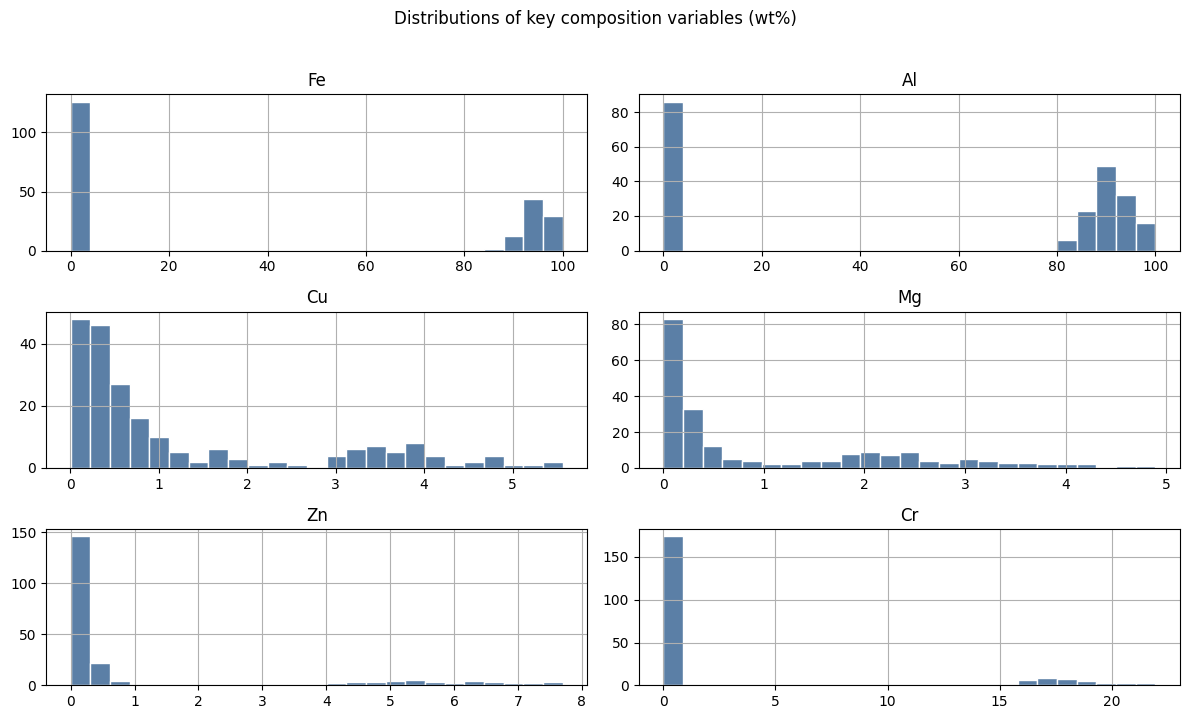

In [18]:
numeric_cols = ["Fe", "Al", "Cu", "Mg", "Zn", "Cr"]
df[numeric_cols].hist(figsize=(12, 7), bins=25, color="#5B7FA6", edgecolor="white")
plt.suptitle("Distributions of key composition variables (wt%)", y=1.02)
plt.tight_layout()
plt.show()


Notice the shapes: `Fe` and `Al` are strongly **bimodal** — a cluster near 0
and a cluster near 90-100 — because these are the base elements of two
different alloy families (Al alloys vs. steels). Minor alloying elements like
`Cu`, `Mg`, `Zn`, `Cr` are **right-skewed**, with most samples near zero and a
long tail — most alloys use only *trace* amounts of any one minor element.


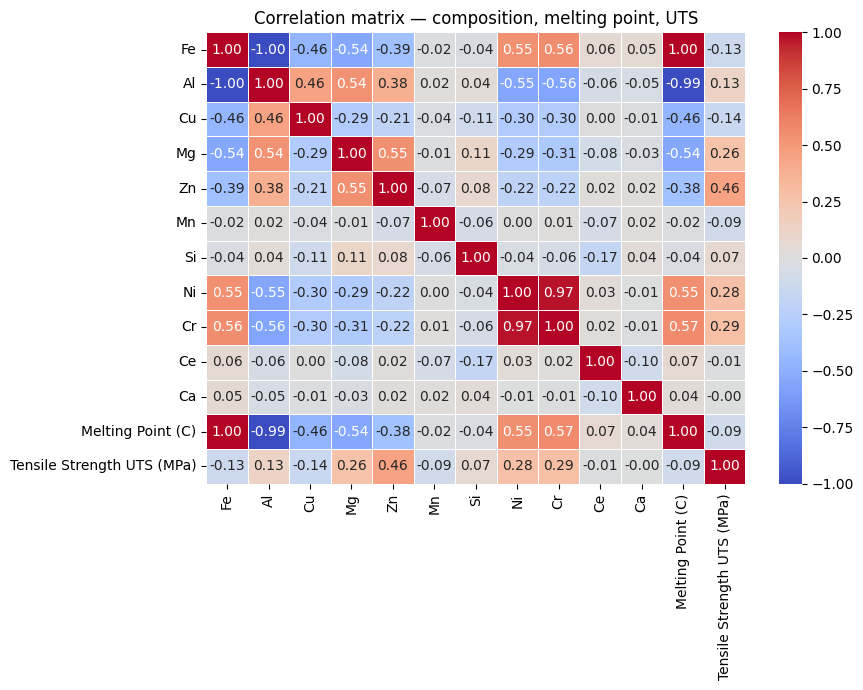

In [19]:
corr = df.select_dtypes(include=np.number).corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white")
plt.title("Correlation matrix — composition, melting point, UTS")
plt.tight_layout()
plt.show()


`Fe` and `Al` are strongly **anti-correlated** — this is not a coincidence,
it's a direct consequence of how alloy families are defined (an alloy is
either Fe-based or Al-based, so one goes up as the other goes down). Look
for which elements correlate most strongly with **Tensile Strength UTS** —
those are the features a predictive model will likely lean on in Section 4.

> **Correlation is not causation.** A strong correlation between an element
> and UTS tells us the two move together in *this* dataset — it does not by
> itself prove that element mechanistically strengthens the alloy. It could
> be confounded by alloy family, heat treatment, or something not measured
> here at all.


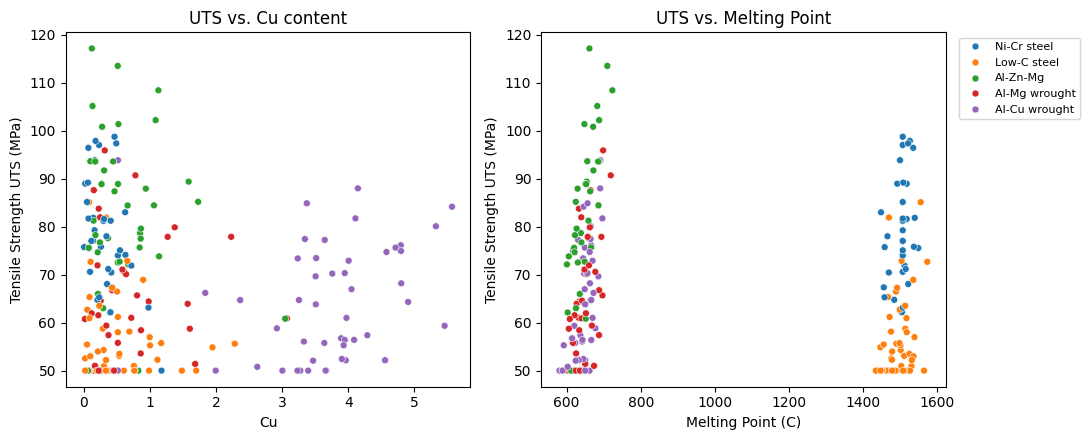

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(data=df, x="Cu", y="Tensile Strength UTS (MPa)",
                 hue="Alloy Family", ax=axes[0], s=25, legend=False)
axes[0].set_title("UTS vs. Cu content")

sns.scatterplot(data=df, x="Melting Point (C)", y="Tensile Strength UTS (MPa)",
                 hue="Alloy Family", ax=axes[1], s=25)
axes[1].set_title("UTS vs. Melting Point")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Once colour-coded by alloy family, apparent trends often **split apart** into
family-specific relationships, or reveal that a trend was really just
separation between families rather than a continuous physical effect within
one family. This is exactly the kind of check that should happen *before*
trusting any model's feature importances.


---
## 4. Machine Learning Workflow — Forward Prediction (Structure → Property)

We now build a supervised regression model: **given an alloy's composition
and melting point, predict its Tensile Strength (UTS).** This is the
*forward* direction — Structure → Property — and follows the exact loop
introduced in the lecture: split → scale → train → cross-validate → tune →
evaluate → interpret.


In [21]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# One-hot encode the categorical Alloy Family so the model can use it as a feature
df_model = pd.get_dummies(df, columns=["Alloy Family"], dtype=int)

TARGET = "Tensile Strength UTS (MPa)"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("Features:", list(X.columns))
print("X shape:", X.shape, " y shape:", y.shape)


Features: ['Fe', 'Al', 'Cu', 'Mg', 'Zn', 'Mn', 'Si', 'Ni', 'Cr', 'Ce', 'Ca', 'Melting Point (C)', 'Alloy Family_Al-Cu wrought', 'Alloy Family_Al-Mg wrought', 'Alloy Family_Al-Zn-Mg', 'Alloy Family_Low-C steel', 'Alloy Family_Ni-Cr steel']
X shape: (212, 17)  y shape: (212,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (169, 17)  Test: (43, 17)


**Scale only after splitting, and fit the scaler on the training set only.**
Fitting a scaler on the full dataset (including the test set) leaks
information about the test distribution into training — a subtle but common
mistake.


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled = scaler.transform(X_test)         # test set only ever gets transformed


In [24]:
model = RandomForestRegressor(random_state=RNG_SEED)

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
print("5-fold CV R^2 scores:", np.round(cv_scores, 3))
print("Mean CV R^2:", round(cv_scores.mean(), 3))


5-fold CV R^2 scores: [0.515 0.329 0.533 0.463 0.411]
Mean CV R^2: 0.45


In [25]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RNG_SEED),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)
print("Best hyperparameters:", grid.best_params_)


Best hyperparameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}


Only now — after tuning is finished — do we touch the held-out test set,
and only once.


In [26]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE  : {mae:.2f} MPa")
print(f"Test RMSE : {rmse:.2f} MPa")
print(f"Test R^2  : {r2:.3f}")


Test MAE  : 8.86 MPa
Test RMSE : 11.33 MPa
Test R^2  : 0.347


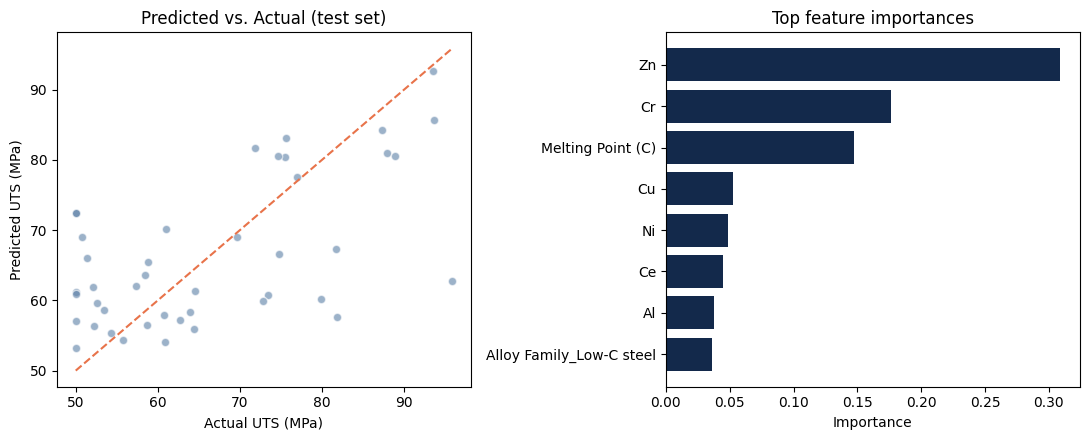

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color="#5B7FA6", edgecolor="white")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "--", color="#E8734A", linewidth=1.5)
axes[0].set_xlabel("Actual UTS (MPa)")
axes[0].set_ylabel("Predicted UTS (MPa)")
axes[0].set_title("Predicted vs. Actual (test set)")

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_,
}).sort_values("Importance", ascending=False).head(8)

axes[1].barh(importance["Feature"][::-1], importance["Importance"][::-1], color="#13294B")
axes[1].set_title("Top feature importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


**Ask, as a materials scientist, not just a data scientist: do the important
features make physical sense?** If the alloying elements known to
strengthen these families (solid-solution or precipitation strengtheners)
rank highly, that's reassuring. If the top feature is something with no
plausible mechanism, that's a signal to look for a data leak or a confound —
**model accuracy is not the same as physical validity.** A model can achieve
a high R² by exploiting a spurious correlation (e.g., alloy-family identity
leaking through a feature) rather than learning a real structure-property
mechanism.


---
## 5. Inverse Design — Property → Structure

Section 4 answered *"given a structure, what property does it have?"*
Inverse design asks the opposite question: **"what structure would give me a
property I want?"** Searching for a good candidate one at a time by forward
prediction, across an enormous compositional/structural space, is
combinatorially hopeless. Instead we:

1. Train an **autoencoder** on synthetic structures to learn a smooth,
   low-dimensional **latent space**.
2. Train a **property predictor** that maps latent vectors → properties.
3. **Freeze both networks** and optimize only a latent vector `z` so the
   predicted properties approach a target — then decode `z` back into a
   structure.

This uses **synthetic** crystal structures and property formulas, exactly as
in the source implementation, so the workflow is fast and fully reproducible.
**These are illustrative surrogate relationships, not real physics or a real
materials database** — the goal here is to understand the inverse-design
*workflow*, not to memorize the numbers.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler as TorchStandardScaler

torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

N = 1000

# 6 structural descriptors: 3 lattice parameters + 3 fractional atomic coordinates
a = np.random.uniform(3, 8, N)
b = np.random.uniform(3, 8, N)
c = np.random.uniform(3, 8, N)
x = np.random.rand(N)
y = np.random.rand(N)
z_coord = np.random.rand(N)

structures = np.column_stack((a, b, c, x, y, z_coord))
print("structures shape:", structures.shape)


structures shape: (1000, 6)


In [29]:
# 3 properties computed from the descriptors by fixed (synthetic) formulas
density = 8 / (a * b * c)
bandgap = 2 * np.sin(x * np.pi) + 1.5 * y + 0.3 * c
strength = 50 * density + 20 * z_coord

properties = np.column_stack((density, bandgap, strength))

print("density  range:", density.min().round(3), "-", density.max().round(3))
print("bandgap  range:", bandgap.min().round(3), "-", bandgap.max().round(3))
print("strength range:", strength.min().round(3), "-", strength.max().round(3))


density  range: 0.018 - 0.234
bandgap  range: 1.456 - 5.806
strength range: 1.423 - 30.196


In [30]:
structure_scaler = StandardScaler()
property_scaler = StandardScaler()

X_struct = structure_scaler.fit_transform(structures)
P_props = property_scaler.fit_transform(properties)

X_struct = torch.tensor(X_struct, dtype=torch.float32)
P_props = torch.tensor(P_props, dtype=torch.float32)


### 5.1 Autoencoder — learning a 2D latent space of structures

6 descriptors compress down to 2 latent numbers. Structurally similar
structures should land near each other in this learned space.


In [31]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(6, 32), nn.ReLU(), nn.Linear(32, 2))
        self.decoder = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 6))

    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z


ae_model = AE()
ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [32]:
ae_losses = []
for epoch in range(5000):
    xhat, z_latent = ae_model(X_struct)
    loss = loss_fn(xhat, X_struct)
    ae_optimizer.zero_grad()
    loss.backward()
    ae_optimizer.step()
    ae_losses.append(loss.item())

print("Final AE reconstruction loss:", ae_losses[-1])


Final AE reconstruction loss: 0.3759881556034088


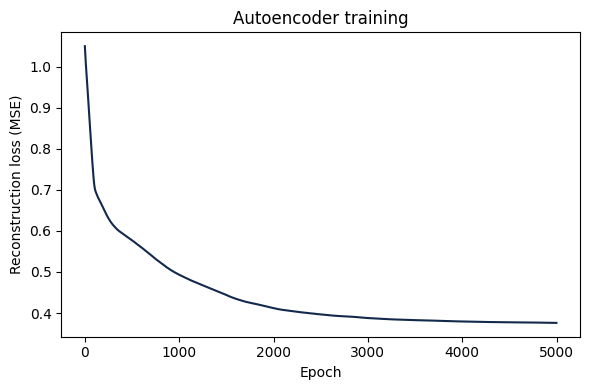

In [33]:
plt.figure(figsize=(6, 4))
plt.plot(ae_losses, color="#13294B")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("Autoencoder training")
plt.tight_layout()
plt.show()


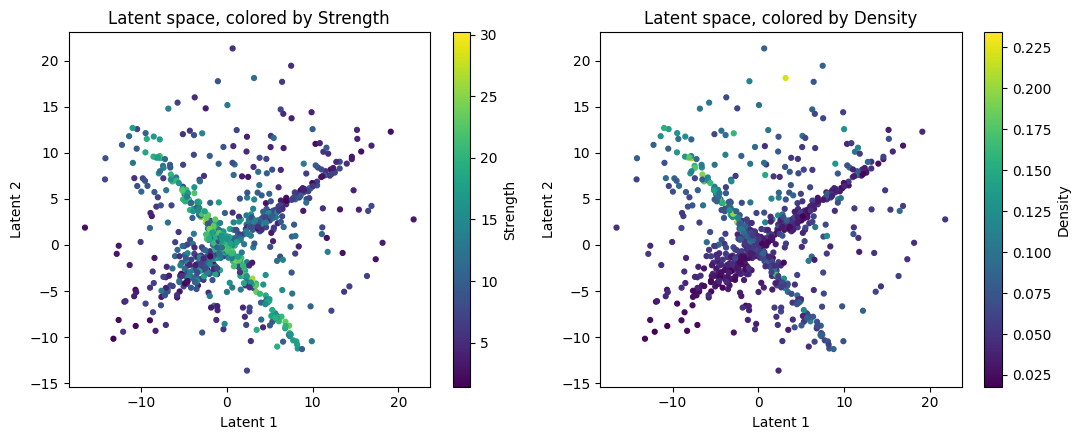

In [34]:
latent = ae_model.encoder(X_struct).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = axes[0].scatter(latent[:, 0], latent[:, 1], c=properties[:, 2], cmap="viridis", s=12)
plt.colorbar(sc0, ax=axes[0], label="Strength")
axes[0].set_xlabel("Latent 1"); axes[0].set_ylabel("Latent 2")
axes[0].set_title("Latent space, colored by Strength")

sc1 = axes[1].scatter(latent[:, 0], latent[:, 1], c=properties[:, 0], cmap="viridis", s=12)
plt.colorbar(sc1, ax=axes[1], label="Density")
axes[1].set_xlabel("Latent 1"); axes[1].set_ylabel("Latent 2")
axes[1].set_title("Latent space, colored by Density")

plt.tight_layout()
plt.show()


If the latent space is well organized, properties should vary **smoothly**
across it — that smoothness is exactly what makes gradient-based search in
this space tractable, unlike the raw, awkward structure space.

### 5.2 Property predictor — Latent → Properties

A small second network learns to predict all 3 properties directly from the
2D latent vector. This is the model we will optimize *against* in the next
step.


In [35]:
class Predictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 3))

    def forward(self, z):
        return self.net(z)


predictor = Predictor()
pred_optimizer = optim.Adam(predictor.parameters(), lr=1e-3)

Z_train = ae_model.encoder(X_struct).detach()
for epoch in range(500):
    pred = predictor(Z_train)
    loss = loss_fn(pred, P_props)
    pred_optimizer.zero_grad()
    loss.backward()
    pred_optimizer.step()

print("Final predictor loss:", loss.item())


Final predictor loss: 0.6274254322052002


### 5.3 Inverse design — optimizing the latent vector

Now the core idea: **freeze the autoencoder and predictor weights**, and
optimize only a latent vector `z` so the predictor's output matches a target
property vector. Then decode the optimized `z` back into a structure.

$$z \leftarrow z - \eta\, \nabla_z \, \lVert \mathrm{Predictor}(z) - \mathrm{target} \rVert^2$$


In [36]:
def inverse_design(target_density, target_bandgap, target_strength, steps=5000, lr=0.05):
    target = np.array([[target_density, target_bandgap, target_strength]])
    target_scaled = property_scaler.transform(target)
    target_t = torch.tensor(target_scaled, dtype=torch.float32)

    z = torch.randn(1, 2, requires_grad=True)
    z_optimizer = optim.Adam([z], lr=lr)
    history = []

    for i in range(steps):
        pred = predictor(z)
        loss = ((pred - target_t) ** 2).mean()
        z_optimizer.zero_grad()
        loss.backward()
        z_optimizer.step()
        history.append(loss.item())

    generated = ae_model.decoder(z).detach().numpy()
    generated = structure_scaler.inverse_transform(generated)
    return generated[0], np.array(history), z.detach().numpy()


#### Attempt 1 — the target used in the lecture: `[density=0.6, bandgap=2.5, strength=40]`

We deliberately run this first attempt **without checking the target against
the training distribution**, exactly as a less experienced user might. Watch
what happens.


In [37]:
gen_1, history_1, z_1 = inverse_design(0.6, 2.5, 40)

print("Generated structure (Attempt 1):")
for name, val in zip(["a", "b", "c", "x", "y", "z"], gen_1):
    print(f"  {name} = {val:.3f}")


Generated structure (Attempt 1):
  a = -1.033
  b = -5.431
  c = 5.123
  x = -3.360
  y = 1.095
  z = 1.255


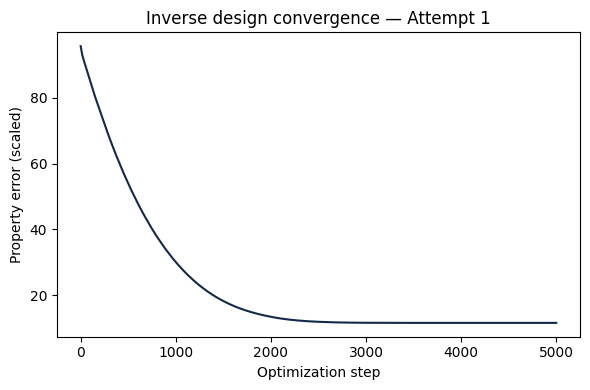

In [38]:
plt.figure(figsize=(6, 4))
plt.plot(history_1, color="#13294B")
plt.xlabel("Optimization step")
plt.ylabel("Property error (scaled)")
plt.title("Inverse design convergence — Attempt 1")
plt.tight_layout()
plt.show()


**Look closely at the generated lattice parameters `a, b, c` above.** Lattice
lengths must be positive — if any of them came out negative, that is not a
bug in the code. It is the model faithfully reporting an **unphysical
answer to an unreasonable question.**

Check the target against what the network actually saw during training:


In [39]:
print("Training data ranges vs. requested target:")
print(f"  density : train [{density.min():.3f}, {density.max():.3f}]   target = 0.6")
print(f"  bandgap : train [{bandgap.min():.3f}, {bandgap.max():.3f}]   target = 2.5")
print(f"  strength: train [{strength.min():.3f}, {strength.max():.3f}]   target = 40")


Training data ranges vs. requested target:
  density : train [0.018, 0.234]   target = 0.6
  bandgap : train [1.456, 5.806]   target = 2.5
  strength: train [1.423, 30.196]   target = 40


The requested `density` and `strength` lie **outside the range the model was
ever trained on**. Asking the decoder to satisfy an out-of-distribution
target forces it to **extrapolate** into a region of latent space it never
learned a physically meaningful mapping for — and extrapolation from a
neural network has no guarantee of physical validity. This is a genuine,
important limitation of this whole family of methods, not a synthetic-data
artifact to be swept under the rug: **a generated candidate is a hypothesis
produced by a surrogate model, not a validated material** — it must still be
checked (here: simple physical plausibility; in a real workflow: DFT and/or
experiment) before anyone believes it.

#### Attempt 2 — a target inside the training distribution

Now repeat the exact same procedure with a target that *is* representative of
what the networks were trained on, to see what a well-posed inverse-design
query looks like.


In [40]:
# well inside the observed training ranges
gen_2, history_2, z_2 = inverse_design(target_density=0.10, target_bandgap=3.0, target_strength=15.0)

print("Generated structure (Attempt 2 — in-distribution target):")
for name, val in zip(["a", "b", "c", "x", "y", "z"], gen_2):
    print(f"  {name} = {val:.3f}")


Generated structure (Attempt 2 — in-distribution target):
  a = 3.832
  b = 4.513
  c = 5.632
  x = 0.294
  y = 0.107
  z = 0.380


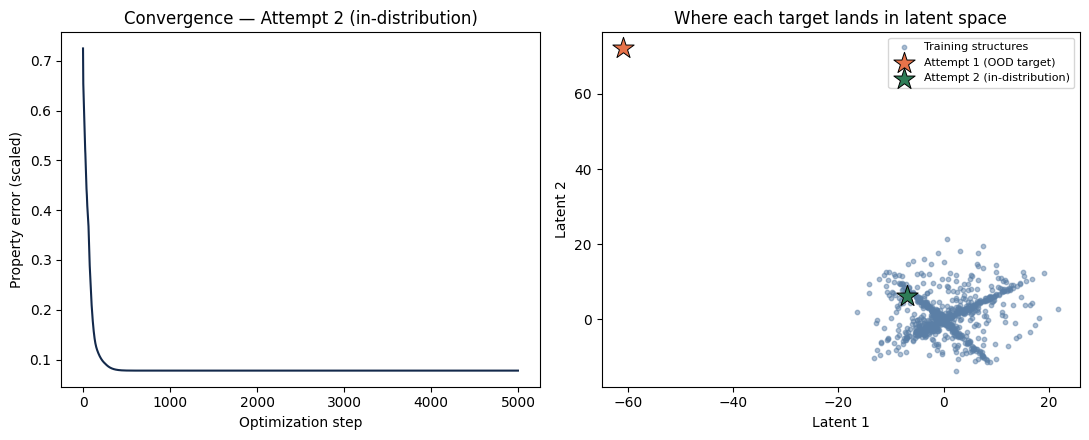

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(history_2, color="#13294B")
axes[0].set_xlabel("Optimization step"); axes[0].set_ylabel("Property error (scaled)")
axes[0].set_title("Convergence — Attempt 2 (in-distribution)")

axes[1].scatter(latent[:, 0], latent[:, 1], c="#5B7FA6", s=10, alpha=0.5, label="Training structures")
axes[1].scatter(z_1[0, 0], z_1[0, 1], c="#E8734A", marker="*", s=260,
                edgecolor="black", linewidth=0.7, label="Attempt 1 (OOD target)")
axes[1].scatter(z_2[0, 0], z_2[0, 1], c="#2E7D57", marker="*", s=260,
                edgecolor="black", linewidth=0.7, label="Attempt 2 (in-distribution)")
axes[1].set_xlabel("Latent 1"); axes[1].set_ylabel("Latent 2")
axes[1].set_title("Where each target lands in latent space")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Attempt 2's candidate lands **inside** the cloud of training structures in
latent space and decodes to physically sensible, positive lattice parameters.
Attempt 1's target pulled the optimizer toward the **edge (or outside)** of
the latent space the model actually learned — visibly confirming, geometrically,
what the range check already told us numerically.

> **The takeaway is not "always pick easy targets."** It is that **any**
> inverse-design output — in-distribution or not — is a *candidate proposed
> by a surrogate model*, not a discovered material. Novel, useful materials
> often *are* found near or outside the edge of known data — that's part of
> why inverse design is exciting — but that is exactly when a generated
> structure most needs independent physical validation (Section 6, and in
> practice: DFT, synthesis, and measurement) before anyone treats it as real.


In [42]:
def write_poscar(filename, a, b, c, x, y, z, atom_type="X"):
    """Minimal illustrative POSCAR writer — assumes an orthogonal cell and
    a single atom at fractional coordinates (x, y, z). For teaching purposes only."""
    with open(filename, "w") as f:
        f.write(f"Generated Structure ({atom_type})\n")
        f.write("1.0\n")
        f.write(f"{a:.6f} 0.000000 0.000000\n")
        f.write(f"0.000000 {b:.6f} 0.000000\n")
        f.write(f"0.000000 0.000000 {c:.6f}\n")
        f.write(f"{atom_type}\n1\nDirect\n")
        f.write(f"{x:.6f} {y:.6f} {z:.6f}\n")
    print(f'POSCAR file "{filename}" written.')

os.makedirs("outputs", exist_ok=True)
write_poscar("outputs/POSCAR_generated_attempt2", *gen_2, atom_type="X")


POSCAR file "outputs/POSCAR_generated_attempt2" written.


---
## 6. From Property Prediction to Atomic-Scale Simulation — MLIP Concept Demo

This section is **conceptual and illustrative, not a production
implementation.** Building a real Machine-Learned Interatomic Potential
(MLIP) requires DFT-quality training data, physically-informed atomic
environment descriptors, and force/stress-matching losses — well beyond the
scope of a single notebook cell. The goal here is to make the *idea*
concrete enough to reason about, and to connect it back to everything above.

### 6.1 The conceptual workflow (pseudocode)

```text
1. DFT calculations on a set of atomic configurations
      configuration (atomic positions + species)
            --DFT-->  total energy, per-atom forces, stress tensor

2. Build a labelled training set
      {atomic environment descriptor_i -> (E_i, F_i, sigma_i)}
      (descriptors encode local atomic neighbourhoods, e.g. via
       symmetry functions / graph representations — NOT raw x,y,z)

3. Train the MLIP
      model: atomic environment descriptor --> (energy, forces, stress)
      loss = weighted_sum(energy_error, force_error, stress_error)
      (conceptually similar to Section 4's regression model, but the
       *output* is now an energy landscape, not a single scalar property)

4. Validate the MLIP
      compare MLIP energies/forces against held-out DFT calculations
      check it reproduces known elastic constants, phonons, defect energies

5. Run Molecular Dynamics (MD) using the MLIP instead of DFT
      MLIP evaluates energy/forces at every timestep, orders of magnitude
      faster than DFT --> enables much larger systems, much longer times

6. (Optional) Active learning loop
      MD run --> flag atomic environments the MLIP is uncertain about
      --> run DFT on just those configurations --> add to training set
      --> retrain MLIP --> repeat
```

### 6.2 What makes an MLIP different from the property-prediction models above

| | Section 4 (Random Forest) | MLIP |
|---|---|---|
| **Input** | Fixed-length composition/structure descriptor | Local atomic environment (per atom, per configuration) |
| **Output** | A single scalar property (UTS) | Energy, forces, and stress — a full potential-energy surface |
| **Training data** | Measured properties | DFT-calculated energies/forces on many configurations |
| **What it enables** | One prediction per structure | Simulating how atoms *move*, at near-DFT accuracy, at MD speed |

The mathematical machinery (a trainable function fit to minimize an error
against labelled data, validated on held-out examples) is genuinely the
same idea threaded through this entire notebook. What changes is the
*output* the model is asked to represent — the challenge grows in scale
and physical constraint, not in kind.


### 6.3 A toy illustration — learning a 1D potential energy curve

To make "a network that learns a potential-energy surface" tangible, here is
a **deliberately toy** example: fit a small neural network to a simple
pairwise **Lennard-Jones potential**, a classic simplified model of how the
energy between two atoms depends on their separation distance. This is
conceptually the simplest possible cousin of what an MLIP does (learn
energy as a function of an atomic-environment descriptor) — but it uses
distance as the only descriptor and has no real quantum-mechanical
grounding. **This is not a real MLIP** — it has no forces, no real atomic
descriptors, no multi-atom environments, and no connection to a real
material. It exists only to make the *shape of the idea* concrete.


In [43]:
def lennard_jones(r, epsilon=1.0, sigma=1.0):
    return 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

r_train = np.linspace(0.85, 3.0, 400)
E_train = lennard_jones(r_train)

r_t = torch.tensor(r_train, dtype=torch.float32).view(-1, 1)
E_t = torch.tensor(E_train, dtype=torch.float32).view(-1, 1)

toy_mlip = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
toy_opt = optim.Adam(toy_mlip.parameters(), lr=5e-3)

for epoch in range(2000):
    pred_E = toy_mlip(r_t)
    loss = loss_fn(pred_E, E_t)
    toy_opt.zero_grad()
    loss.backward()
    toy_opt.step()

print("Final toy-MLIP fit loss:", loss.item())


Final toy-MLIP fit loss: 0.00022201667889021337


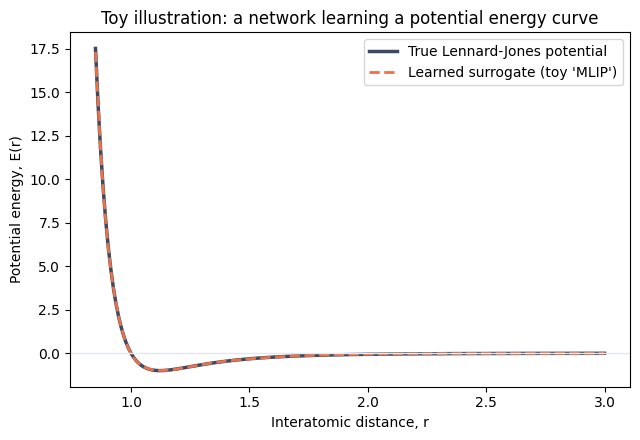

In [44]:
r_test = np.linspace(0.85, 3.0, 200)
with torch.no_grad():
    E_pred = toy_mlip(torch.tensor(r_test, dtype=torch.float32).view(-1, 1)).numpy().flatten()

plt.figure(figsize=(6.5, 4.5))
plt.plot(r_test, lennard_jones(r_test), color="#3B4A63", linewidth=2.5, label="True Lennard-Jones potential")
plt.plot(r_test, E_pred, "--", color="#E8734A", linewidth=2, label="Learned surrogate (toy 'MLIP')")
plt.axhline(0, color="#E3E7EE", linewidth=1)
plt.xlabel("Interatomic distance, r")
plt.ylabel("Potential energy, E(r)")
plt.title("Toy illustration: a network learning a potential energy curve")
plt.legend()
plt.tight_layout()
plt.show()


Once a network like this can predict energy (and, with automatic
differentiation, forces = -dE/dr) accurately from atomic environment
descriptors, it can replace DFT **inside** an MD loop — evaluating
energies and forces at every timestep — at a small fraction of the
computational cost, which is precisely what makes large-scale, long-time MD
of real materials tractable with near-DFT accuracy.


---
## Summary — what this notebook demonstrated

| Section | Question answered | Key tool |
|---|---|---|
| 1–2. Inspection & Cleaning | Can I trust this dataset? | `.info()`, `pd.to_numeric(errors="coerce")`, group-wise imputation |
| 3. EDA | What does the data look like, and does it make physical sense? | histograms, correlation heatmap |
| 4. Forward prediction | Structure → Property | `RandomForestRegressor`, cross-validation, `GridSearchCV` |
| 5. Inverse design | Property → Structure | autoencoder + latent-space gradient optimization |
| 6. MLIP concept | Structure/atomic-environment → energy landscape → MD | conceptual workflow + toy potential-fitting demo |

Throughout, three distinctions were deliberately kept visible rather than
glossed over:

- **Correlation vs. causation** (Section 3) — variables moving together in
  the data does not prove a mechanism.
- **Model accuracy vs. physical validity** (Section 4) — a high R² is
  necessary but not sufficient; feature importances must still make
  physical sense.
- **Generated candidates vs. validated materials** (Section 5) — an inverse
  design output, in- or out-of-distribution, is a hypothesis from a
  surrogate model, and needs independent (physics-based, and ultimately
  experimental) validation before it is treated as a real material.

**The overall message:** AI does not replace materials science — it
provides computational tools that let us extract knowledge from materials
data, build predictive models, explore enormous design spaces, and
increasingly perform inverse design, while physics-based calculations and
experiments remain essential for validating what these models propose.
